# 04. XAI — SHAP

## Question
**모델은 어떤 특성을 근거로 거래를 사기로 판단하는가?**

## Objective
SHAP을 활용해 모델의 전반적인 판단 요인과
개별 거래의 사기 판단에 기여한 변수를 분석한다.

PermutationExplainer explainer: 2it [00:13, 13.87s/it]                                                                 


=== [Local SHAP] Selected Sample Index: 13706 ===


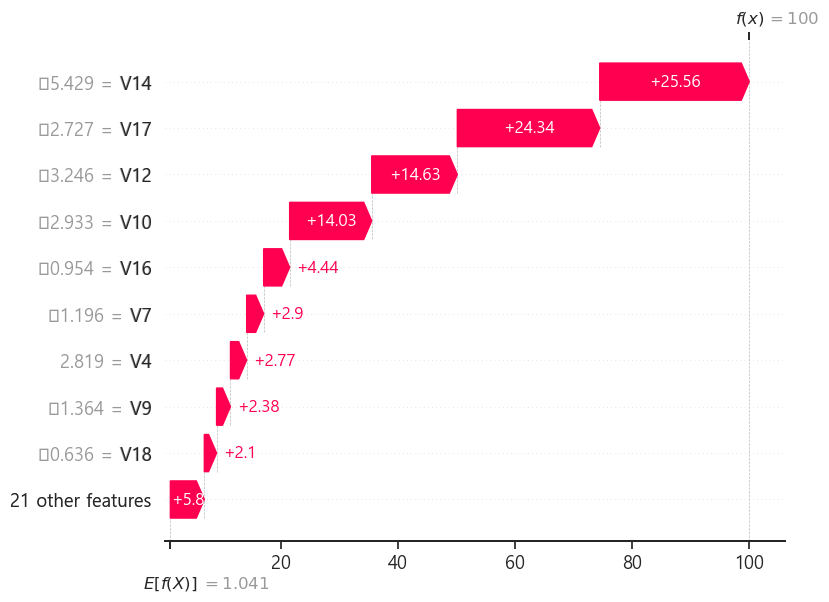

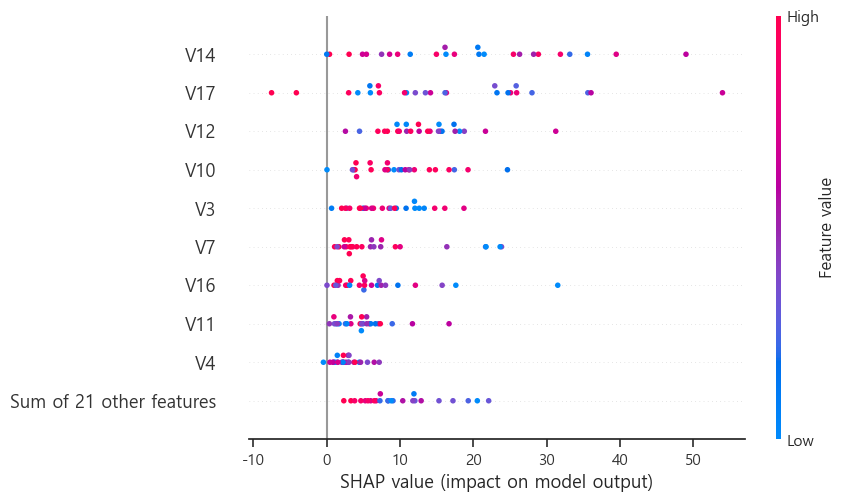

In [95]:
import shap

val_x_df = val_x.copy()

raw_fraud_scores = -best_ee.decision_function(val_x_df) # 이상치일수록 양수(+)로 만듦
min_s = raw_fraud_scores.min()
max_s = np.quantile(raw_fraud_scores, 0.999)

def scaled_anomaly_score(X):
    raw = -best_ee.decision_function(X)
    # Min-Max Scaling 적용하여 0~100점 반환
    scaled = (raw - min_s) / (max_s - min_s) * 100
    return np.clip(scaled, 0, 100)

background = shap.sample(val_x_df, 100, random_state = 42)
explainer = shap.Explainer(scaled_anomaly_score, background)

# fraud_indices = np.where((val_y == 1) & (best_ee.predict(val_x) == -1))[0] : 탐지에 성공한 사기 거래(TP)만 설명
# TP 중 가장 이상치 점수가 높은 거래
pred_labels = best_ee.predict(val_x_df)

fraud_df = pd.DataFrame({
    "idx": np.arange(len(val_x_df)),
    "raw_score": raw_fraud_scores,
    "pred": pred_labels,
    "y": val_y.values,
})

tp = fraud_df[(fraud_df["y"] == 1) & (fraud_df["pred"] == -1)]
p = tp.sort_values("raw_score", ascending=False) # 이상치 점수가 높은 순 정렬

sample_idx = int(tp.iloc[len(tp)//2]["idx"])
sample_data = val_x_df.iloc[[sample_idx]]

# local shap
shap_values_sample = explainer(sample_data)

print(f"=== [Local SHAP] Selected Sample Index: {sample_idx} ===")
shap.plots.waterfall(shap_values_sample[0], max_display=10)

# global shap : TP 사기 거래 전체(25건) 대상 변수 중요도 분석
fraud_indices = tp["idx"].values
sample_df = val_x_df.iloc[fraud_indices]

shap_values_all = explainer(sample_df)

shap.plots.beeswarm(shap_values_all, max_display = 10)

### SHAP Score Interpretation

- Elliptic Envelope의 `decision_function`은 값이 낮을수록 이상치이므로, 부호를 반전해 **높을수록 사기 위험이 높은 방향**으로 변환

- SHAP 분석에서도 동일한 Risk Score 함수를 사용하기 위해, 부호를 반전한 점수를 **0~100으로 Min-Max Scaling**하고 상위 99.9% Quantile을 상한값으로 적용 -> 극단적인 이상치 하나로 전체 점수가 왜곡되는 문제를 방지

- 오탐·미탐이 섞이지 않도록 TP(탐지에 성공한 사기 거래)만 대상으로 분석

- Local 분석에서는 TP 중 Risk Score가 중앙값에 가까운 거래를 선택해 전형적인 사기 사례를 설명하고, Global 분석에서는 TP 전체의 SHAP 값을 집계

- **SHAP > 0** → 해당 변수가 사기 Risk Score를 높이는 방향으로 기여
- **SHAP < 0** → 해당 변수가 정상 방향으로 기여

`shap.Explainer()`에 Scaling 함수를 직접 전달하고, 계산 비용을 고려해 background 데이터를 100개로 제한